# 2D Likelihood Contour: GW Frequency vs Pulsar Distance

This notebook generates **N** random pulsars and **M** random continuous
gravitational wave (CGW) sources, then sweeps the PTA log-likelihood over
a 2D grid of:

- **GW frequency** ($\log_{10} f_{\rm gw}$) of one CW source (x-axis)
- **Pulsar distance** (PX, in kpc) of one target pulsar (y-axis)

The result is a contour plot showing how the likelihood constrains these
two parameters jointly.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.notebook_utils import (
    build_cw_injectors,
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_1d_logL,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 42

## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [3]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


Generated 10 pulsars
Example .par:
PSR           J1834-0701_00
RAJ           18:34:29.80260
DECJ          -07:01:17.6778
F0            443.4391679646
F1            -2.481624e-15
PEPOCH        57000.0
PX            0.7354
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_val = float(pp_tuple[i].param_value("PX"))
    f0 = float(pp_tuple[i].param_value("F0"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  F0={f0:.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1834-0701_00  PX(dist)=0.74 kpc  F0=443.4 Hz
  Pulsar 1:        J2324+3129_01  PX(dist)=1.63 kpc  F0=414.4 Hz
  Pulsar 2:        J0853+5835_02  PX(dist)=1.61 kpc  F0=357.5 Hz
  Pulsar 3:        J0527+0616_03  PX(dist)=2.08 kpc  F0=125.5 Hz
  Pulsar 4:        J1811-1654_04  PX(dist)=2.45 kpc  F0=488.3 Hz
  Pulsar 5:        J0440-0348_05  PX(dist)=2.21 kpc  F0=117.5 Hz
  Pulsar 6:        J1752+6913_06  PX(dist)=1.67 kpc  F0=230.3 Hz
  Pulsar 7:        J0432-4744_07  PX(dist)=2.17 kpc  F0=290.3 Hz
  Pulsar 8:        J1029+4142_08  PX(dist)=2.58 kpc  F0=380.1 Hz
  Pulsar 9:        J1918-1300_09  PX(dist)=0.85 kpc  F0=215.3 Hz

All 10 pulsars loaded.


## Set up M CW sources and inject into TOAs

We place M continuous gravitational wave sources at random sky locations with
random nHz-band GW frequencies and strain amplitude $h = 10^{-14}$.

In [5]:
TRUE_LOG10_FGW = -8.0

cw_injectors, _ = build_cw_injectors(
    pint_models, n_sources=M_CW_SOURCES, rng=rng, log10_h=-14.0,
)

for m, inj in enumerate(cw_injectors):
    print(
        f"  CW source {m}: cos_gwtheta={inj.param_spec['cos_gwtheta']:.3f}, "
        f"gwphi={inj.param_spec['gwphi']:.3f}, "
        f"log10_fgw={inj.param_spec['log10_fgw']:.2f}"
    )

gp, config = inject_and_build_config(synthetic, cw_injectors)

# Capture the true injected value for source 0 if the swept param is frequency
if "log10_fgw" == "log10_fgw":
    TRUE_LOG10_FGW = float(cw_injectors[0].param_spec["log10_fgw"])

print(f"\nPTA config built with {M_CW_SOURCES} CW sources.")
print(f"Global params: {gp.names}")


  CW source 0: cos_gwtheta=-0.600, gwphi=0.046, log10_fgw=-7.43

PTA config built with 1 CW sources.
Global params: ('cw0_log10_h', 'cw0_cos_gwtheta', 'cw0_gwphi', 'cw0_log10_fgw', 'cw0_cos_inc', 'cw0_psi', 'cw0_phase0')


/home/hector/NYU/PTA/jax_pint/JaxPINT/jaxpint/notebook_utils.py:410: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config = PTAConfig(


## 2D likelihood sweep: log10(f_gw) vs pulsar distance

We sweep the GW frequency of CW source 0 (`cw0_log10_fgw`) and the
distance of pulsar 0 (`PX`) over a 2D grid, evaluating the PTA
log-likelihood at each point.

Note: the frequency sweep is kept narrow around the true value — moving far
off-resonance detunes the signal sharply and the likelihood collapses.

In [6]:
TARGET_PULSAR = 0
true_distance = float(pp_tuple[TARGET_PULSAR].param_value("PX"))
print(f"Pulsar {TARGET_PULSAR} true distance: {true_distance:.3f} kpc")
print(f"True log10(f_gw) for CW source 0: {TRUE_LOG10_FGW:.4f}")

half_window_px = 0.005           # kpc
half_window_fgw = 0.05           # log10 units
log10_fgw_grid = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    1000,
)
distance_grid = np.linspace(
    true_distance - half_window_px,
    true_distance + half_window_px,
    1000,
)

def eval_logL_2d(log10_fgw_val, px_val):
    gp_mod = gp.with_value("cw0_log10_fgw", log10_fgw_val)
    pp_mod_0 = pp_tuple[TARGET_PULSAR].with_value("PX", px_val)
    pp_mod = pp_tuple[:TARGET_PULSAR] + (pp_mod_0,) + pp_tuple[TARGET_PULSAR + 1:]
    return pta_logL(gp_mod, pp_mod, config)

print(f"Computing {len(log10_fgw_grid)} x {len(distance_grid)} = "
      f"{len(log10_fgw_grid) * len(distance_grid)} likelihood evaluations...")
logL_2d = sweep_2d_logL(eval_logL_2d, log10_fgw_grid, distance_grid)
print("Done.")


Pulsar 0 true distance: 0.735 kpc
True log10(f_gw) for CW source 0: -7.4262
Computing 1000 x 1000 = 1000000 likelihood evaluations...
Done.


## Colormesh plot

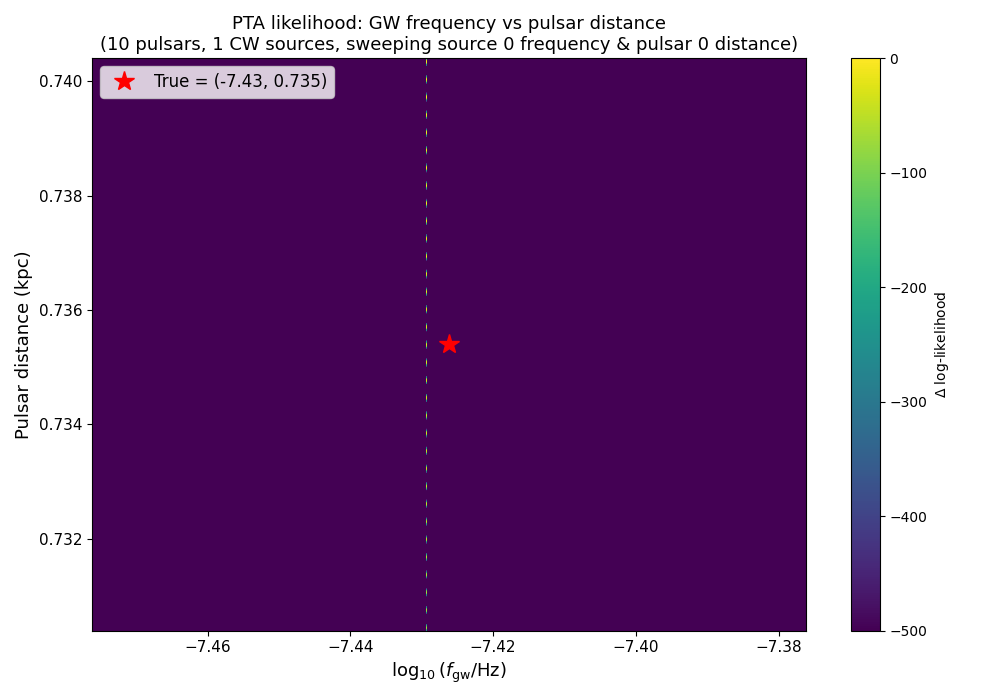

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

mesh = plot_2d_delta_logL(
    ax, log10_fgw_grid, distance_grid, logL_2d,
    true_xy=(TRUE_LOG10_FGW, true_distance),
)
ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel("Pulsar distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA likelihood: GW frequency vs pulsar distance\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, "
    f"sweeping source 0 frequency & pulsar {TARGET_PULSAR} distance)",
    fontsize=13,
)
ax.legend(fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()


## 1D likelihood sweep: log10(f_gw) at true distance

Slice through the 2D surface at the true pulsar distance to show
how the likelihood depends on GW frequency alone.

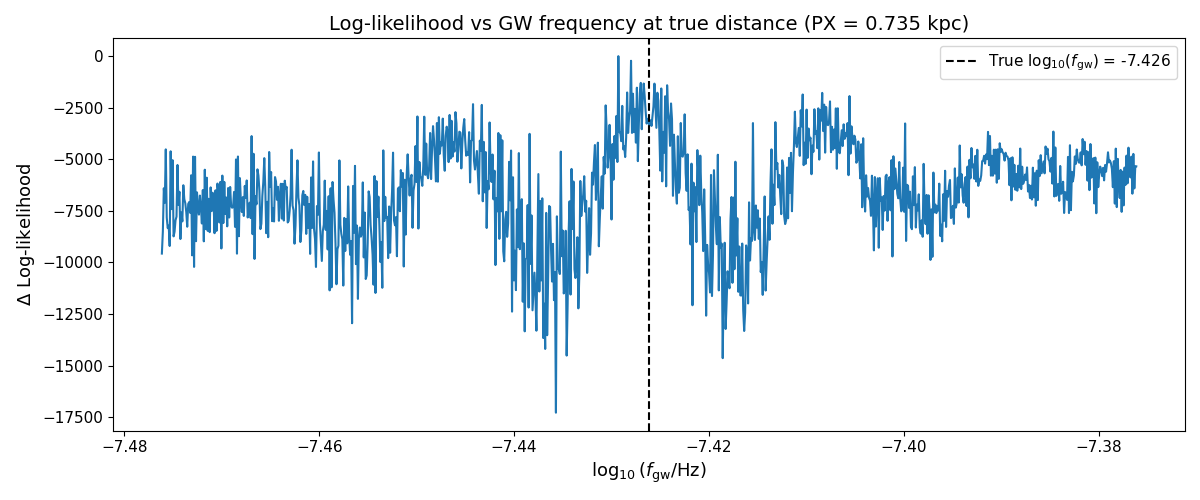

In [8]:
log10_fgw_fine = np.linspace(
    TRUE_LOG10_FGW - half_window_fgw,
    TRUE_LOG10_FGW + half_window_fgw,
    1000,
)

def _eval_1d(f, _td=jnp.float64(true_distance)):
    return eval_logL_2d(f, _td)

logL_1d = sweep_1d_logL(_eval_1d, log10_fgw_fine)
delta_1d = logL_1d - logL_1d.max()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(log10_fgw_fine, delta_1d, linewidth=1.5)
ax.axvline(
    TRUE_LOG10_FGW, color="black", linestyle="--", linewidth=1.5,
    label=f"True log$_{{10}}(f_{{\\rm gw}})$ = {TRUE_LOG10_FGW:.3f}",
)
ax.set_xlabel(r"$\log_{10}(f_{\rm gw}/\rm Hz)$", fontsize=13)
ax.set_ylabel(r"$\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"Log-likelihood vs GW frequency at true distance "
    f"(PX = {true_distance:.3f} kpc)",
    fontsize=14,
)
ax.legend(fontsize=11)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()
